# HAR Project: Frame-Based vs. Temporal Models
**Human Activity Recognition Notebook**

note for self - managed to find a way to upload and process the 16gb HAR folder containing videos and create two datasets with training, validation, and testing implemented.

notice: using colab with google drive folder upload was not optimal due to free storage limitations, needed to use API Key from Kaggle to upload video folders to Colab storage and extracted video frames (16 of each video per class) to google drive instead.

In [1]:
# mount google drive — we only use Drive to store the extracted frames (small)
# the raw videos will download straight into Colab's local /content/ storage (temporary)
# this way the 15.94GB dataset never touches our Drive storage
from google.colab import drive
drive.mount('/content/drive')

import os

# raw videos land here in Colab's local storage (wiped when the session ends, that's fine)
DATASET_ROOT = '/content/HAR_Dataset'

# extracted frames go here on Drive (permanent, only ~1-2GB)
FRAMES_ROOT = '/content/drive/MyDrive/HAR_Frames'

os.makedirs(DATASET_ROOT, exist_ok=True)
os.makedirs(FRAMES_ROOT,  exist_ok=True)

print('Paths set.')
print(f'  Videos  -> {DATASET_ROOT}  (temporary, local)')
print(f'  Frames  -> {FRAMES_ROOT}  (permanent, Drive)')


Mounted at /content/drive
Paths set.
  Videos  -> /content/HAR_Dataset  (temporary, local)
  Frames  -> /content/drive/MyDrive/HAR_Frames  (permanent, Drive)


In [2]:
# download the HAR dataset directly from Kaggle into Colab's local storage
# uses kagglehub — Kaggle's newer download library — with your KGAT_... API token
#
# one-time setup before running this cell:
#   1. click the key icon (Secrets) in the left Colab sidebar
#   2. click 'Add new secret'
#   3. name it exactly: KAGGLE_API_TOKEN
#   4. paste your KGAT_... token as the value
#   5. toggle 'Notebook access' on

import os
from google.colab import userdata
import kagglehub

# read the token from Colab Secrets and set it as an environment variable
# kagglehub will automatically pick it up from here
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# download the dataset — kagglehub returns the local path where it was saved
download_path = kagglehub.dataset_download(
    "sharjeelmazhar/human-activity-recognition-video-dataset"
)

# point DATASET_ROOT at the downloaded folder
DATASET_ROOT = download_path

# confirm the class folders are present
classes = sorted(os.listdir(DATASET_ROOT))
print('Download path:', DATASET_ROOT)
print('Classes found:', classes)
print('Number of classes:', len(classes))


Using Colab cache for faster access to the 'human-activity-recognition-video-dataset' dataset.
Download path: /kaggle/input/human-activity-recognition-video-dataset
Classes found: ['Human Activity Recognition - Video Dataset']
Number of classes: 1


In [3]:
# the dataset downloads with an extra wrapper folder inside
# we need to go one level deeper to reach the actual class folders
DATASET_ROOT = os.path.join(DATASET_ROOT, 'Human Activity Recognition - Video Dataset')

# now we re-check the classes
classes = sorted(os.listdir(DATASET_ROOT))
print('Classes found:', classes)
print('Number of classes:', len(classes))

Classes found: ['Clapping', 'Meet and Split', 'Sitting', 'Standing Still', 'Walking', 'Walking While Reading Book', 'Walking While Using Phone']
Number of classes: 7


In [4]:
# extract frames from every video and save them as jpg files
# we do this once up front so the training loop reads images instead of decoding video every epoch
# reading jpgs from Drive is much faster than re-decoding video files each time

import cv2
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

# how many frames to pull from each video clip
# 16 frames is a common choice: enough to capture motion, small enough to load quickly
FRAMES_PER_VIDEO = 16

# supported video file extensions
video_extensions = {'.mp4', '.avi', '.mov', '.mkv'}

for cls in classes:
    cls_video_dir = os.path.join(DATASET_ROOT, cls)

    # collect all video files in this class folder
    videos = [f for f in Path(cls_video_dir).iterdir()
              if f.suffix.lower() in video_extensions]

    print(f'\n{cls}: {len(videos)} videos')

    for video_path in tqdm(videos, desc=cls):

        # each video gets its own subfolder named after the video file (without extension)
        # e.g. HAR_Frames/Clapping/clip_001/frame_0000.jpg, frame_0001.jpg, ...
        out_dir = os.path.join(FRAMES_ROOT, cls, video_path.stem)

        # skip if we already extracted this clip
        if os.path.exists(out_dir) and len(os.listdir(out_dir)) == FRAMES_PER_VIDEO:
            continue

        os.makedirs(out_dir, exist_ok=True)

        # open the video and count how many frames it has
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames == 0:
            cap.release()
            continue

        # pick FRAMES_PER_VIDEO positions spread evenly across the video
        # this gives us a uniform temporal sample rather than just the first 16 frames
        frame_indices = np.linspace(0, total_frames - 1, FRAMES_PER_VIDEO, dtype=int)

        for i, frame_idx in enumerate(frame_indices):
            # seek to the chosen position and read that frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()

            if ret:
                # resize frame to 224x224 before saving to keep file sizes small
                frame = cv2.resize(frame, (224, 224))
                cv2.imwrite(os.path.join(out_dir, f'frame_{i:04d}.jpg'), frame)

        cap.release()

print('\nFrame extraction complete.')


Clapping: 146 videos


Clapping:   0%|          | 0/146 [00:00<?, ?it/s]


Meet and Split: 147 videos


Meet and Split:   0%|          | 0/147 [00:00<?, ?it/s]


Sitting: 156 videos


...


Walking While Reading Book: 176 videos


Walking While Reading Book:   0%|          | 0/176 [00:00<?, ?it/s]


Walking While Using Phone: 143 videos


Walking While Using Phone:   0%|          | 0/143 [00:00<?, ?it/s]


Frame extraction complete.


In [5]:
# build a list of all clips and split into train, validation, and test sets
# a "clip" here means a folder of extracted frames belonging to one activity class

from sklearn.model_selection import train_test_split

# map each class name to a number the model can predict
# e.g. {'Clapping': 0, 'Meet and Split': 1, 'Sitting': 2, ...}
class_to_idx = {cls: i for i, cls in enumerate(classes)}
print('Label map:', class_to_idx)

# collect all clip paths and their labels as two separate lists
# train_test_split expects inputs and labels as parallel lists
all_clip_paths = []
all_labels     = []

for cls in classes:
    cls_frames_dir = os.path.join(FRAMES_ROOT, cls)

    if not os.path.exists(cls_frames_dir):
        continue

    for clip_name in os.listdir(cls_frames_dir):
        clip_path = os.path.join(cls_frames_dir, clip_name)

        if os.path.isdir(clip_path):
            all_clip_paths.append(clip_path)
            all_labels.append(class_to_idx[cls])

# first split: carve out 15% as the test set, keep the remaining 85%
# stratify=all_labels ensures each split has a proportional mix of all 7 classes
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_clip_paths, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

# second split: divide the remaining 85% into 70% train and 15% validation
# test_size=0.176 of 85% gives us roughly 15% of the total dataset
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.176,
    random_state=42,
    stratify=train_val_labels
)

# zip paths and labels back together into (clip_path, label) pairs for the Dataset classes
train_clips = list(zip(train_paths, train_labels))
val_clips   = list(zip(val_paths,   val_labels))
test_clips  = list(zip(test_paths,  test_labels))

print(f'\nTotal clips : {len(all_clip_paths)}')
print(f'Train       : {len(train_clips)}')
print(f'Validation  : {len(val_clips)}')
print(f'Test        : {len(test_clips)}')

Label map: {'Clapping': 0, 'Meet and Split': 1, 'Sitting': 2, 'Standing Still': 3, 'Walking': 4, 'Walking While Reading Book': 5, 'Walking While Using Phone': 6}

Total clips : 1113
Train       : 779
Validation  : 167
Test        : 167


In [6]:
# define transforms and two PyTorch Dataset classes
#
# FrameDataset    -> returns ONE frame per clip (used by the CNN baseline)
# SequenceDataset -> returns ALL 16 frames per clip as a sequence (used by CNN + LSTM)

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random

# 224x224 is the standard input size for most pre-trained CNNs (ResNet, EfficientNet, etc.)
IMG_SIZE = 224

# training transform: resize, light augmentation, convert to tensor, normalize
# normalization uses ImageNet mean/std because we will use a pre-trained ImageNet backbone
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# validation/test transform: no augmentation, just resize + normalize
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# --- FrameDataset ---
# each call to __getitem__ loads one single frame from a clip
# during training we pick a random frame (acts as extra augmentation)
# during validation we always pick the middle frame so results are consistent
class FrameDataset(Dataset):
    def __init__(self, clips, transform=None, is_train=True):
        self.clips     = clips       # list of (clip_folder_path, label)
        self.transform = transform
        self.is_train  = is_train

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip_dir, label = self.clips[idx]

        # get a sorted list of all frame files in this clip folder
        frame_files = sorted(os.listdir(clip_dir))

        # pick which frame to load
        if self.is_train:
            chosen_frame = random.choice(frame_files)
        else:
            chosen_frame = frame_files[len(frame_files) // 2]

        # open the frame image as RGB and apply the transform
        img = Image.open(os.path.join(clip_dir, chosen_frame)).convert('RGB')

        if self.transform:
            img = self.transform(img)

        # returns a single frame tensor (3, 224, 224) and its class label
        return img, label


# --- SequenceDataset ---
# each call to __getitem__ loads ALL frames from a clip and stacks them into a sequence
# the LSTM will process these frames in order to understand motion over time
class SequenceDataset(Dataset):
    def __init__(self, clips, transform=None, n_frames=FRAMES_PER_VIDEO):
        self.clips     = clips       # list of (clip_folder_path, label)
        self.transform = transform
        self.n_frames  = n_frames   # how many frames we expect per clip

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip_dir, label = self.clips[idx]

        frame_files = sorted(os.listdir(clip_dir))

        # if a clip has fewer frames than expected (e.g. a very short video),
        # repeat the last frame until we reach n_frames
        while len(frame_files) < self.n_frames:
            frame_files.append(frame_files[-1])
        frame_files = frame_files[:self.n_frames]

        # load each frame, apply the transform, and collect into a list
        frame_tensors = []
        for fname in frame_files:
            img = Image.open(os.path.join(clip_dir, fname)).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frame_tensors.append(img)

        # stack the list of (3, 224, 224) tensors into one (16, 3, 224, 224) tensor
        # shape: (n_frames, channels, height, width)
        sequence = torch.stack(frame_tensors, dim=0)

        # returns the full sequence tensor and its class label
        return sequence, label


# instantiate all six datasets (train/val/test x frame/sequence)
frame_train_dataset = FrameDataset(train_clips, transform=train_transform, is_train=True)
frame_val_dataset   = FrameDataset(val_clips,   transform=val_transform,   is_train=False)
frame_test_dataset  = FrameDataset(test_clips,  transform=val_transform,   is_train=False)

seq_train_dataset   = SequenceDataset(train_clips, transform=train_transform)
seq_val_dataset     = SequenceDataset(val_clips,   transform=val_transform)
seq_test_dataset    = SequenceDataset(test_clips,  transform=val_transform)

print(f'Frame dataset    — train: {len(frame_train_dataset)} | val: {len(frame_val_dataset)} | test: {len(frame_test_dataset)}')
print(f'Sequence dataset — train: {len(seq_train_dataset)} | val: {len(seq_val_dataset)} | test: {len(seq_test_dataset)}')

Frame dataset    — train: 779 | val: 167 | test: 167
Sequence dataset — train: 779 | val: 167 | test: 167


In [7]:
# create DataLoaders for both dataset types
# a DataLoader handles batching, shuffling, and loading data in parallel

# batch size for single frames - each item is one image (3, 224, 224)
FRAME_BATCH_SIZE = 16

# smaller batch size for sequences - each item is 16 images stacked, so ~16x heavier in memory
SEQ_BATCH_SIZE = 8

# num_workers controls how many background threads pre-load data while the GPU is busy
# 2 is safe on Colab; set to 0 if you see multiprocessing errors
NUM_WORKERS = 2

# frame-based loaders (for the CNN baseline)
frame_train_loader = DataLoader(frame_train_dataset, batch_size=FRAME_BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
frame_val_loader   = DataLoader(frame_val_dataset,   batch_size=FRAME_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
frame_test_loader  = DataLoader(frame_test_dataset,  batch_size=FRAME_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# sequence-based loaders (for the CNN + LSTM model)
seq_train_loader   = DataLoader(seq_train_dataset, batch_size=SEQ_BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
seq_val_loader     = DataLoader(seq_val_dataset,   batch_size=SEQ_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
seq_test_loader    = DataLoader(seq_test_dataset,  batch_size=SEQ_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('DataLoaders ready.')

DataLoaders ready.


Frame batch shape    : torch.Size([16, 3, 224, 224])
Sequence batch shape : torch.Size([8, 16, 3, 224, 224])
Frame labels         : [4, 5, 3, 1, 6, 5, 3, 5, 5, 0, 4, 2, 1, 4, 4, 6]


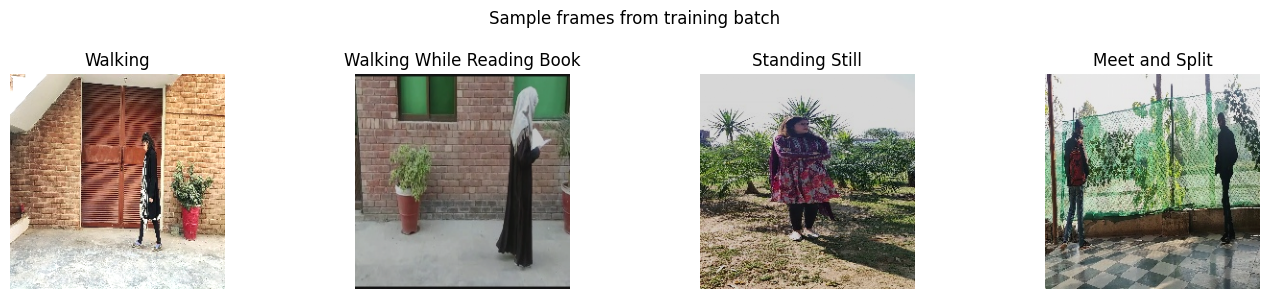

In [8]:
# sanity check: pull one batch from each loader and confirm shapes look right
# also visualize a few sample frames so we can see the data is loading correctly

import matplotlib.pyplot as plt

# pull one batch from each loader
sample_frames, sample_frame_labels = next(iter(frame_train_loader))
sample_seqs,   sample_seq_labels   = next(iter(seq_train_loader))

print(f'Frame batch shape    : {sample_frames.shape}')  # expected: (16, 3, 224, 224)
print(f'Sequence batch shape : {sample_seqs.shape}')    # expected: (8, 16, 3, 224, 224)
print(f'Frame labels         : {sample_frame_labels.tolist()}')

# to display the images we need to undo the normalization we applied earlier
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# show the first 4 frames from the frame batch with their class names
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for i, ax in enumerate(axes):
    # un-normalize: multiply by std and add mean, then clamp to [0, 1] for display
    img_display = (sample_frames[i] * std + mean).clamp(0, 1)
    # permute from (C, H, W) to (H, W, C) for matplotlib
    img_display = img_display.permute(1, 2, 0).numpy()

    ax.imshow(img_display)
    ax.set_title(classes[sample_frame_labels[i].item()])
    ax.axis('off')

plt.suptitle('Sample frames from training batch')
plt.tight_layout()
plt.show()

In [10]:
# --- Frame CNN (baseline model) ---
# we load a ResNet-18 that was pre-trained on ImageNet
# ResNet-18 is a well-established CNN architecture that extracts spatial features from images
# pre-trained means its weights already know how to detect edges, textures, and shapes
# we only need to fine-tune it for our 7 activity classes

import torch.nn as nn
from torchvision import models

NUM_CLASSES = len(classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class FrameCNN(nn.Module):
    def __init__(self, num_classes=7, freeze_backbone=True):
        super(FrameCNN, self).__init__()

        # load ResNet-18 with pre-trained ImageNet weights
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        if freeze_backbone:
            # freeze all backbone layers so their ImageNet weights don't get overwritten
            # we only want to train the new classification head we add below
            for param in self.backbone.parameters():
                param.requires_grad = False

        # ResNet-18's final layer outputs 512 features
        # we replace it with a new layer that outputs 7 scores (one per activity class)
        # this new layer starts untrained and will learn during our training loop
        self.backbone.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # x shape: (batch_size, 3, 224, 224) — one frame per sample
        # returns logits shape: (batch_size, 7) — one score per class
        return self.backbone(x)


# instantiate the model and move it to GPU
frame_model = FrameCNN(num_classes=NUM_CLASSES, freeze_backbone=True)
frame_model = frame_model.to(device)

# count how many parameters are actually being trained (should only be the final layer)
trainable = sum(p.numel() for p in frame_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in frame_model.parameters())
print(f'FrameCNN — trainable params: {trainable:,} / {total:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


FrameCNN — trainable params: 3,591 / 11,180,103


In [11]:
# --- CNN + LSTM (temporal model) ---
# this model processes a full sequence of 16 frames per clip
# step 1: the CNN backbone extracts a 512-dim feature vector from each individual frame
# step 2: the LSTM receives the 16 feature vectors in order and learns how they change over time
# step 3: the final hidden state of the LSTM is passed to a classifier for the activity prediction
# this allows the model to reason about motion, not just appearance

class CNNLSTMModel(nn.Module):
    def __init__(self, num_classes=7, hidden_size=256, num_lstm_layers=1, freeze_backbone=True):
        super(CNNLSTMModel, self).__init__()

        # load the same ResNet-18 backbone
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        if freeze_backbone:
            for param in backbone.parameters():
                param.requires_grad = False

        # remove the final classification layer from ResNet
        # we only want the feature extractor part (outputs a 512-dim vector per frame)
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])

        # the LSTM takes the sequence of 512-dim CNN features as input
        # hidden_size controls how much memory the LSTM has for tracking motion over time
        # batch_first=True means input shape is (batch, sequence, features)
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_lstm_layers,
            batch_first=True
        )

        # final classifier: maps the LSTM's last hidden state to 7 class scores
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, 16, 3, 224, 224)
        batch_size, n_frames, C, H, W = x.shape

        # reshape so we can pass all frames through the CNN in one go
        # merge batch and frame dimensions: (batch_size * 16, 3, 224, 224)
        x = x.view(batch_size * n_frames, C, H, W)

        # extract features from every frame: output shape (batch_size * 16, 512, 1, 1)
        features = self.cnn(x)

        # flatten spatial dimensions: (batch_size * 16, 512)
        features = features.view(batch_size * n_frames, -1)

        # restore sequence structure: (batch_size, 16, 512)
        features = features.view(batch_size, n_frames, -1)

        # pass the sequence of features through the LSTM
        # lstm_out shape: (batch_size, 16, hidden_size)
        lstm_out, _ = self.lstm(features)

        # take only the last timestep's output — it has seen all 16 frames by this point
        last_hidden = lstm_out[:, -1, :]  # shape: (batch_size, hidden_size)

        # classify based on the final hidden state
        # returns logits shape: (batch_size, 7)
        return self.classifier(last_hidden)


# instantiate the model and move it to GPU
temporal_model = CNNLSTMModel(num_classes=NUM_CLASSES, hidden_size=256, freeze_backbone=True)
temporal_model = temporal_model.to(device)

trainable = sum(p.numel() for p in temporal_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in temporal_model.parameters())
print(f'CNNLSTMModel — trainable params: {trainable:,} / {total:,}')

CNNLSTMModel — trainable params: 790,279 / 11,966,791


In [12]:
# --- Training: Frame CNN (baseline) ---
# trains the CNN model on single frames using frame_train_loader
# saves the best validation checkpoint to Drive as frame_cnn_best.pth

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model        = frame_model
train_loader = frame_train_loader
val_loader   = frame_val_loader

# Adam optimizer — filter skips frozen backbone layers
optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
max_epochs = 20
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
criterion  = nn.CrossEntropyLoss()

frame_train_loss_log = []
frame_train_acc_log  = []
frame_val_loss_log   = []
frame_val_acc_log    = []

best_val_acc   = 0.0
best_ckpt_path = '/content/drive/MyDrive/frame_cnn_best.pth'

for epoch in range(1, max_epochs + 1):

    # ----- training phase -----
    model.train()
    running_loss    = 0.0
    running_correct = 0
    total_train     = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits = model(inputs)
        loss   = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * inputs.size(0)
        predicted_labels = logits.argmax(dim=1)
        running_correct += (predicted_labels == labels).sum().item()
        total_train     += inputs.size(0)

    epoch_train_loss = running_loss    / total_train
    epoch_train_acc  = running_correct / total_train

    # ----- validation phase -----
    # no gradient computation needed since we are only evaluating, not updating weights
    model.eval()
    val_running_loss    = 0.0
    val_running_correct = 0
    total_val           = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss   = criterion(logits, labels)

            val_running_loss    += loss.item() * inputs.size(0)
            predicted_labels     = logits.argmax(dim=1)
            val_running_correct += (predicted_labels == labels).sum().item()
            total_val           += inputs.size(0)

    epoch_val_loss = val_running_loss    / total_val
    epoch_val_acc  = val_running_correct / total_val

    frame_train_loss_log.append(epoch_train_loss)
    frame_train_acc_log.append(epoch_train_acc)
    frame_val_loss_log.append(epoch_val_loss)
    frame_val_acc_log.append(epoch_val_acc)

    # save model weights whenever validation accuracy hits a new best
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_ckpt_path)

    scheduler.step()

    print(f'[Frame CNN] Epoch [{epoch}/{max_epochs}]  '
          f'Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.3f}  |  '
          f'Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.3f}')

print(f'\nBest validation accuracy (Frame CNN): {best_val_acc:.3f}')

Using device: cuda
[Frame CNN] Epoch [1/20]  Train Loss: 1.9716, Acc: 0.190  |  Val Loss: 1.8910, Acc: 0.216
[Frame CNN] Epoch [2/20]  Train Loss: 1.8267, Acc: 0.285  |  Val Loss: 1.7777, Acc: 0.317
[Frame CNN] Epoch [3/20]  Train Loss: 1.7169, Acc: 0.365  |  Val Loss: 1.6634, Acc: 0.407
[Frame CNN] Epoch [4/20]  Train Loss: 1.6254, Acc: 0.452  |  Val Loss: 1.5692, Acc: 0.509
[Frame CNN] Epoch [5/20]  Train Loss: 1.5537, Acc: 0.512  |  Val Loss: 1.4934, Acc: 0.539
[Frame CNN] Epoch [6/20]  Train Loss: 1.4711, Acc: 0.555  |  Val Loss: 1.4203, Acc: 0.599
[Frame CNN] Epoch [7/20]  Train Loss: 1.4030, Acc: 0.614  |  Val Loss: 1.3645, Acc: 0.611
[Frame CNN] Epoch [8/20]  Train Loss: 1.3676, Acc: 0.624  |  Val Loss: 1.3164, Acc: 0.629
[Frame CNN] Epoch [9/20]  Train Loss: 1.3158, Acc: 0.644  |  Val Loss: 1.2756, Acc: 0.665
[Frame CNN] Epoch [10/20]  Train Loss: 1.2904, Acc: 0.653  |  Val Loss: 1.2450, Acc: 0.653
[Frame CNN] Epoch [11/20]  Train Loss: 1.2506, Acc: 0.661  |  Val Loss: 1.2160, 

In [13]:
# --- Training: CNN + LSTM (temporal model) ---
# trains the temporal model on 16-frame sequences using seq_train_loader
# saves the best validation checkpoint to Drive as cnn_lstm_best.pth

model        = temporal_model
train_loader = seq_train_loader
val_loader   = seq_val_loader

# re-initialize optimizer and scheduler for the new model
optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
max_epochs = 20
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
criterion  = nn.CrossEntropyLoss()

temporal_train_loss_log = []
temporal_train_acc_log  = []
temporal_val_loss_log   = []
temporal_val_acc_log    = []

best_val_acc   = 0.0
best_ckpt_path = '/content/drive/MyDrive/cnn_lstm_best.pth'

for epoch in range(1, max_epochs + 1):

    # ----- training phase -----
    model.train()
    running_loss    = 0.0
    running_correct = 0
    total_train     = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits = model(inputs)
        loss   = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * inputs.size(0)
        predicted_labels = logits.argmax(dim=1)
        running_correct += (predicted_labels == labels).sum().item()
        total_train     += inputs.size(0)

    epoch_train_loss = running_loss    / total_train
    epoch_train_acc  = running_correct / total_train

    # ----- validation phase -----
    # no gradient computation needed since we are only evaluating, not updating weights
    model.eval()
    val_running_loss    = 0.0
    val_running_correct = 0
    total_val           = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss   = criterion(logits, labels)

            val_running_loss    += loss.item() * inputs.size(0)
            predicted_labels     = logits.argmax(dim=1)
            val_running_correct += (predicted_labels == labels).sum().item()
            total_val           += inputs.size(0)

    epoch_val_loss = val_running_loss    / total_val
    epoch_val_acc  = val_running_correct / total_val

    temporal_train_loss_log.append(epoch_train_loss)
    temporal_train_acc_log.append(epoch_train_acc)
    temporal_val_loss_log.append(epoch_val_loss)
    temporal_val_acc_log.append(epoch_val_acc)

    # save model weights whenever validation accuracy hits a new best
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_ckpt_path)

    scheduler.step()

    print(f'[CNN+LSTM] Epoch [{epoch}/{max_epochs}]  '
          f'Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.3f}  |  '
          f'Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.3f}')

print(f'\nBest validation accuracy (CNN+LSTM): {best_val_acc:.3f}')

[CNN+LSTM] Epoch [1/20]  Train Loss: 1.6623, Acc: 0.487  |  Val Loss: 1.2783, Acc: 0.641
[CNN+LSTM] Epoch [2/20]  Train Loss: 1.0580, Acc: 0.700  |  Val Loss: 0.7600, Acc: 0.778
[CNN+LSTM] Epoch [3/20]  Train Loss: 0.7137, Acc: 0.791  |  Val Loss: 0.5309, Acc: 0.826
[CNN+LSTM] Epoch [4/20]  Train Loss: 0.5965, Acc: 0.819  |  Val Loss: 0.4341, Acc: 0.880
[CNN+LSTM] Epoch [5/20]  Train Loss: 0.4527, Acc: 0.868  |  Val Loss: 0.3498, Acc: 0.916
[CNN+LSTM] Epoch [6/20]  Train Loss: 0.4066, Acc: 0.888  |  Val Loss: 0.3072, Acc: 0.910
[CNN+LSTM] Epoch [7/20]  Train Loss: 0.3172, Acc: 0.906  |  Val Loss: 0.2894, Acc: 0.904
[CNN+LSTM] Epoch [8/20]  Train Loss: 0.2560, Acc: 0.942  |  Val Loss: 0.2479, Acc: 0.946
[CNN+LSTM] Epoch [9/20]  Train Loss: 0.2389, Acc: 0.937  |  Val Loss: 0.2091, Acc: 0.928
[CNN+LSTM] Epoch [10/20]  Train Loss: 0.2204, Acc: 0.928  |  Val Loss: 0.1826, Acc: 0.946
[CNN+LSTM] Epoch [11/20]  Train Loss: 0.1679, Acc: 0.953  |  Val Loss: 0.1702, Acc: 0.946
[CNN+LSTM] Epoch [1

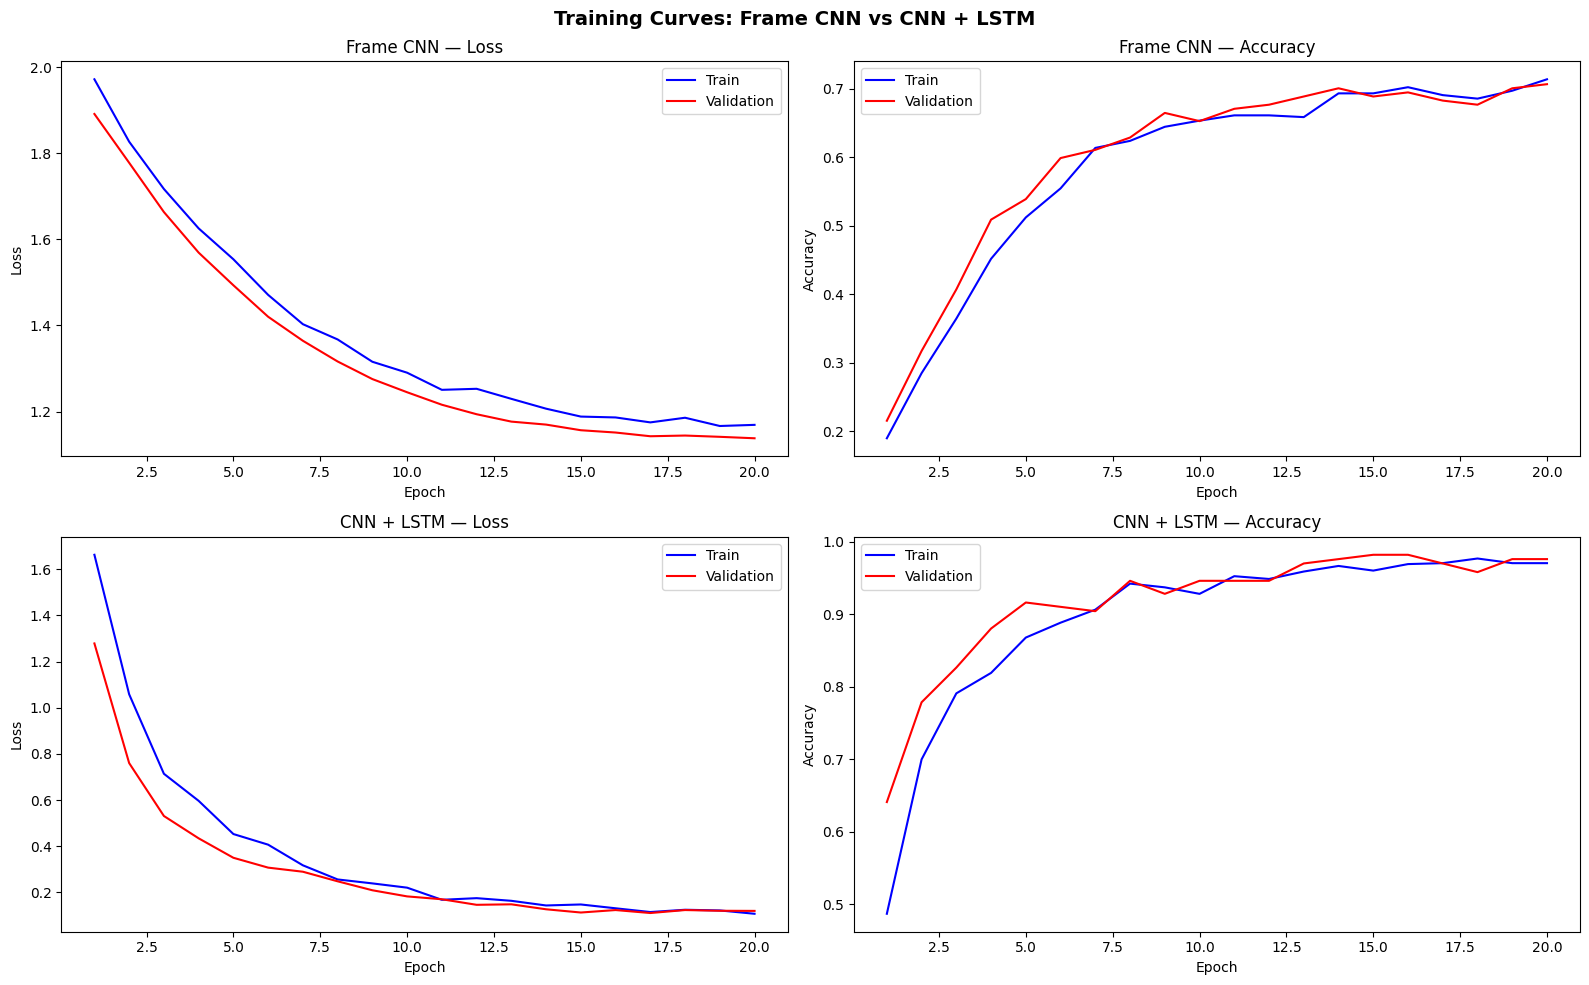

In [14]:
# plot training and validation curves for both models side by side
# this makes it easy to compare how each model learned over the 20 epochs

import matplotlib.pyplot as plt

epochs = range(1, max_epochs + 1)

plt.figure(figsize=(16, 10))

# --- Frame CNN loss ---
plt.subplot(2, 2, 1)
plt.plot(epochs, frame_train_loss_log, 'b', label='Train')
plt.plot(epochs, frame_val_loss_log,   'r', label='Validation')
plt.title('Frame CNN — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- Frame CNN accuracy ---
plt.subplot(2, 2, 2)
plt.plot(epochs, frame_train_acc_log, 'b', label='Train')
plt.plot(epochs, frame_val_acc_log,   'r', label='Validation')
plt.title('Frame CNN — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# --- CNN + LSTM loss ---
plt.subplot(2, 2, 3)
plt.plot(epochs, temporal_train_loss_log, 'b', label='Train')
plt.plot(epochs, temporal_val_loss_log,   'r', label='Validation')
plt.title('CNN + LSTM — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- CNN + LSTM accuracy ---
plt.subplot(2, 2, 4)
plt.plot(epochs, temporal_train_acc_log, 'b', label='Train')
plt.plot(epochs, temporal_val_acc_log,   'r', label='Validation')
plt.title('CNN + LSTM — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.suptitle('Training Curves: Frame CNN vs CNN + LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

--- Frame CNN — Test Set Results ---

                            precision    recall  f1-score   support

                  Clapping       0.94      0.73      0.82        22
            Meet and Split       0.50      0.41      0.45        22
                   Sitting       0.70      0.83      0.76        23
            Standing Still       0.69      0.77      0.73        26
                   Walking       0.55      0.46      0.50        26
Walking While Reading Book       0.65      0.85      0.73        26
 Walking While Using Phone       0.55      0.50      0.52        22

                  accuracy                           0.65       167
                 macro avg       0.65      0.65      0.64       167
              weighted avg       0.65      0.65      0.65       167



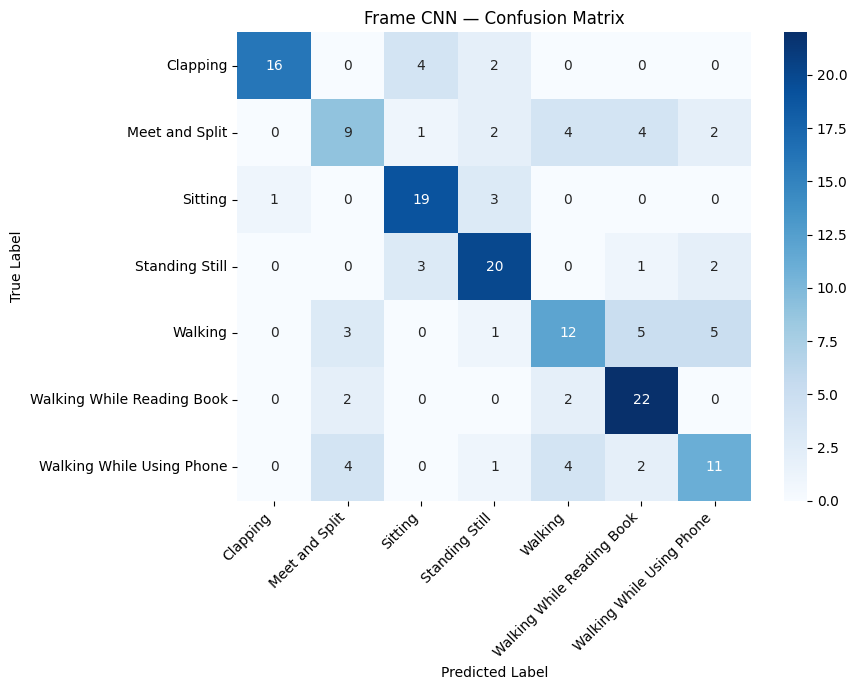

In [15]:
# --- Evaluation: Frame CNN ---
# loads the best saved checkpoint and runs it on the test set
# prints per-class precision, recall, and F1, and displays a confusion matrix

import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

frame_model.load_state_dict(torch.load('/content/drive/MyDrive/frame_cnn_best.pth', map_location=device))
frame_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in frame_test_loader:
        inputs = inputs.to(device)
        preds  = frame_model(inputs).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print('--- Frame CNN — Test Set Results ---\n')
print(classification_report(all_labels, all_preds, target_names=classes))

# confusion matrix: rows = true class, columns = predicted class
# off-diagonal cells show where the model confused one activity for another
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Frame CNN — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

--- CNN + LSTM — Test Set Results ---

                            precision    recall  f1-score   support

                  Clapping       1.00      1.00      1.00        22
            Meet and Split       0.96      1.00      0.98        22
                   Sitting       1.00      1.00      1.00        23
            Standing Still       1.00      1.00      1.00        26
                   Walking       0.96      0.88      0.92        26
Walking While Reading Book       0.96      1.00      0.98        26
 Walking While Using Phone       0.95      0.95      0.95        22

                  accuracy                           0.98       167
                 macro avg       0.98      0.98      0.98       167
              weighted avg       0.98      0.98      0.98       167



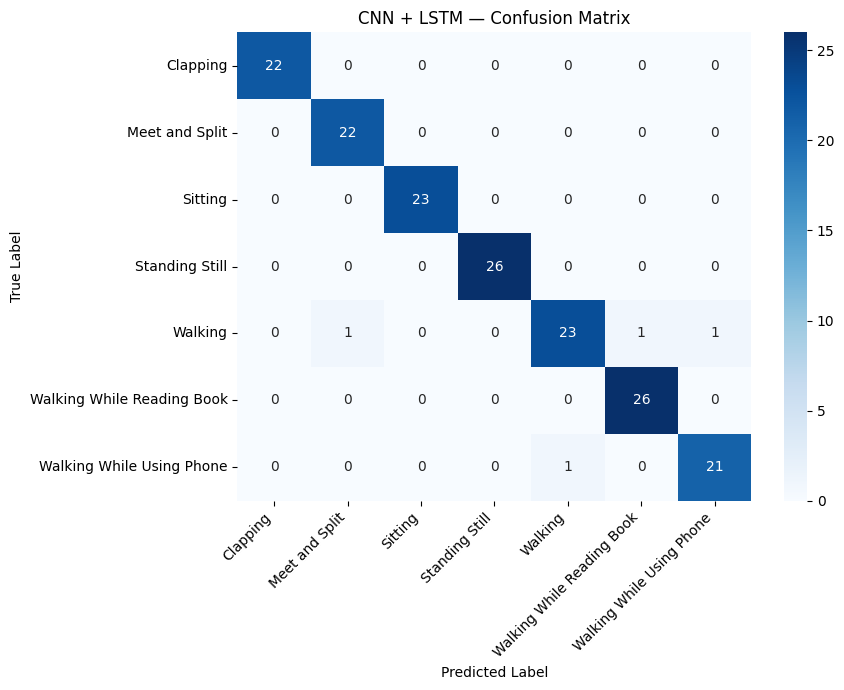

In [16]:
# --- Evaluation: CNN + LSTM ---
# loads the best saved checkpoint and runs it on the test set
# prints per-class precision, recall, and F1, and displays a confusion matrix

temporal_model.load_state_dict(torch.load('/content/drive/MyDrive/cnn_lstm_best.pth', map_location=device))
temporal_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in seq_test_loader:
        inputs = inputs.to(device)
        preds  = temporal_model(inputs).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print('--- CNN + LSTM — Test Set Results ---\n')
print(classification_report(all_labels, all_preds, target_names=classes))

# confusion matrix: rows = true class, columns = predicted class
# off-diagonal cells show where the model confused one activity for another
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('CNN + LSTM — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

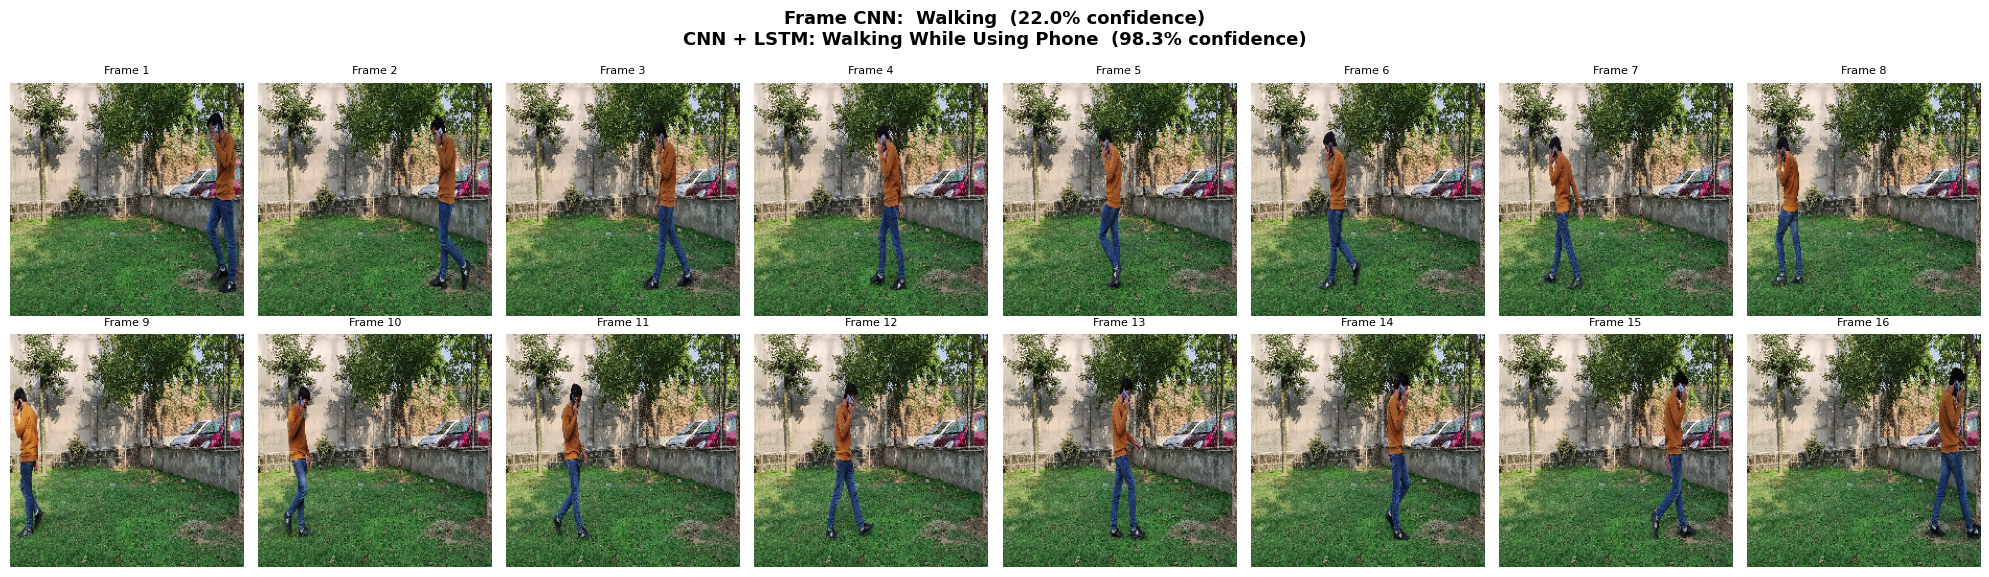


Frame CNN  prediction : Walking  (22.0%)
CNN+LSTM   prediction : Walking While Using Phone  (98.3%)


In [19]:
# --- Demo: Side-by-Side Prediction ---
# given a raw video file, runs both models and displays their predicted activity
# uses the same preprocessing as training so the models see consistent input

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

def predict_video(video_path, frame_model, temporal_model, classes, device, n_frames=16):
    """
    Extract frames from a video, run both models, and display results.
    """

    # --- step 1: extract n_frames evenly spaced frames from the video ---
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        print('Error: could not read video file.')
        return

    frame_indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)

    raw_frames  = []   # original BGR frames for display
    pil_frames  = []   # PIL frames for transforms

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (224, 224))
            raw_frames.append(frame)
            # convert BGR (OpenCV format) to RGB (PIL format)
            pil_frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    cap.release()

    # pad if video was too short
    while len(pil_frames) < n_frames:
        pil_frames.append(pil_frames[-1])
        raw_frames.append(raw_frames[-1])

    # --- step 2: apply the same val transform used during training ---
    frame_tensors = [val_transform(img) for img in pil_frames]

    # --- step 3: Frame CNN prediction (middle frame only) ---
    middle_frame  = frame_tensors[n_frames // 2].unsqueeze(0).to(device)  # shape: (1, 3, 224, 224)
    frame_model.eval()
    with torch.no_grad():
        frame_logits  = frame_model(middle_frame)
        frame_pred    = classes[frame_logits.argmax(dim=1).item()]
        frame_conf    = torch.softmax(frame_logits, dim=1).max().item()

    # --- step 4: CNN+LSTM prediction (full 16-frame sequence) ---
    sequence = torch.stack(frame_tensors, dim=0).unsqueeze(0).to(device)  # shape: (1, 16, 3, 224, 224)
    temporal_model.eval()
    with torch.no_grad():
        temporal_logits = temporal_model(sequence)
        temporal_pred   = classes[temporal_logits.argmax(dim=1).item()]
        temporal_conf   = torch.softmax(temporal_logits, dim=1).max().item()

    # --- step 5: display the 16 frames and predictions ---
    fig, axes = plt.subplots(2, 8, figsize=(20, 6))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        # convert BGR to RGB for display
        ax.imshow(cv2.cvtColor(raw_frames[i], cv2.COLOR_BGR2RGB))
        ax.set_title(f'Frame {i+1}', fontsize=8)
        ax.axis('off')
        # highlight the middle frame used by the Frame CNN
        if i == n_frames // 2:
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)

    plt.suptitle(
        f'Frame CNN:  {frame_pred}  ({frame_conf:.1%} confidence)\n'
        f'CNN + LSTM: {temporal_pred}  ({temporal_conf:.1%} confidence)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print(f'\nFrame CNN  prediction : {frame_pred}  ({frame_conf:.1%})')
    print(f'CNN+LSTM   prediction : {temporal_pred}  ({temporal_conf:.1%})')


# --- run the demo ---
# replace this path with any video clip you want to test
# you can upload a video to Colab using the Files panel on the left
VIDEO_PATH = '/content/test_har.mp4'  # <-- replace with your video path

predict_video(
    video_path     = VIDEO_PATH,
    frame_model    = frame_model,
    temporal_model = temporal_model,
    classes        = classes,
    device         = device
)